# Notebook 05 — CARMA Kalman Filter (Python validation)

Runs discrete-observation Kalman filters for CARMA$(2,1)$ (temperature) and CARMA$(3,2)$ (log-price) using the QMLE-estimated parameters from notebooks 06/07. The state-space form is

$$dZ_t = A\,Z_t\,dt + \mathbf{e}_p\,dL_t, \qquad Y_k = \mathbf{b}^\top Z_{t_k} + \varepsilon_k$$

with Van Loan discretization for the process noise covariance. Fit quality is assessed via log-likelihood, AIC, and Ljung-Box tests on standardized innovations.

**Inputs:** `data/deseasonalised/temp_resid.csv`, `data/deseasonalised/price_resid_dejumped.csv`  
**Outputs:** `y_hat_price.npy`, `x_hat_price.npy` (Kalman-filtered states)

### CARMA(2,1) — temperature

Parameters from the R QMLE estimation in notebook 06, Step 3 (hourly scale, $h = 1$ hr):
- AR: $a_1 = 0.9091$, $a_2 = 0.0250$ (hr$^{-1}$ scale)
- MA: $b_0 = 1$, $b_1 = 0.5692$
- Scale: $\sigma = 0.7921$

The observation equation is $Y_k = b_0 X_{1,k} + b_1 X_{2,k}$ (companion-state convention). The Python filter below uses $b_1 = 0.5$ as a conservative initial value to validate filter stability; the definitive annual-scale parameters are in notebook 06 Step 4.

In [2]:
import numpy as np
import pandas as pd
from scipy.linalg import expm

temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res   = temp_resid["temp_deseasoned"].copy()
time_temp  = pd.to_datetime(temp_res.index)

y = temp_res.to_numpy(dtype=float)
t= np.arange(len(y), dtype=float)

# CARMA(2,1) parameters (from notebook 06, h = 1/8760 yr scale)
a1    = 0.9094457
a2    = 0.0249784
b0    = 1.0000000
b1    = 0.5
sigma = 0.7921462

yerr = np.full_like(y, 1e-6, dtype=float)

def van_loan_discretization(A, G, dt):
    """Compute discrete-time transition matrix F and process noise covariance Q
    for the continuous-time SDE  dX = A X dt + G dW  observed at step dt."""
    n = A.shape[0]
    M = np.block([
        [A,                G @ G.T       ],
        [np.zeros((n, n)), -A.T          ]
    ]) * dt
    E = expm(M)
    F = E[:n, :n]
    Q = E[:n, n:] @ F.T
    return F, Q

def kalman_filter_carma21(t, y, a1, a2, b0, b1, sigma, yerr=None,
                          x0=None, P0=None, jitter=1e-10):
    t    = np.asarray(t, dtype=float)
    y    = np.asarray(y, dtype=float)
    yerr = np.full_like(y, 1e-6) if yerr is None else np.asarray(yerr, dtype=float)

    if not np.all(np.diff(t) > 0):
        raise ValueError("Time index must be strictly increasing")

    n, m = len(y), 2

    # Continuous-time CARMA(2,1) companion form
    A = np.array([[0.0, 1.0], [-a2, -a1]], dtype=float)
    L = np.array([[0.0], [sigma]],         dtype=float)
    H = np.array([[b0, b1]],               dtype=float)

    x_prev = np.zeros(m) if x0 is None else np.asarray(x0, dtype=float)
    P_prev = np.eye(m) * 1000.0 if P0 is None else np.asarray(P0, dtype=float)

    x_pred   = np.zeros((n, m))
    P_pred   = np.zeros((n, m, m))
    x_filt   = np.zeros((n, m))
    P_filt   = np.zeros((n, m, m))
    y_pred   = np.zeros(n)
    resid    = np.zeros(n)
    std_resid = np.zeros(n)
    S_all    = np.zeros(n)
    loglik   = 0.0

    for k in range(n):
        # Prediction step
        if k == 0:
            xk_pred, Pk_pred = x_prev, P_prev
        else:
            F, Q = van_loan_discretization(A, L, t[k] - t[k - 1])
            xk_pred = F @ x_prev
            Pk_pred = F @ P_prev @ F.T + Q

        # Update step
        Rk  = float(yerr[k] ** 2 + jitter)
        mu  = float(H @ xk_pred)
        S   = float(H @ Pk_pred @ H.T + Rk)
        v   = y[k] - mu
        K   = (Pk_pred @ H.T) / S

        x_prev = xk_pred + K[:, 0] * v
        P_prev = Pk_pred - K @ H @ Pk_pred

        x_pred[k], P_pred[k] = xk_pred, Pk_pred
        x_filt[k], P_filt[k] = x_prev,  P_prev
        y_pred[k]    = mu
        resid[k]     = v
        std_resid[k] = v / np.sqrt(S)
        S_all[k]     = S
        loglik      += -0.5 * (np.log(2 * np.pi) + np.log(S) + v ** 2 / S)

    return dict(A=A, L=L, H=H,
                x_pred=x_pred, P_pred=P_pred,
                x_filt=x_filt, P_filt=P_filt,
                y_pred=y_pred, resid=resid,
                std_resid=std_resid, S=S_all, loglik=loglik)

res  = kalman_filter_carma21(t=t, y=y, a1=a1, a2=a2, b0=b0, b1=b1, sigma=sigma, yerr=yerr)

y_hat      = res["y_pred"]
innov      = res["resid"]
z          = res["std_resid"]
loglik     = res["loglik"]
x_hat      = res["x_pred"]
y_hat_temp = y_hat.copy()
x_hat_temp = x_hat.copy()

aic  = -2 * loglik
rmse = np.sqrt(np.mean((y - y_hat) ** 2))
mae  = np.mean(np.abs(y - y_hat))

print("=== CARMA(2,1) — TEMPERATURE ===")
print(f"  Log-likelihood: {loglik:.4f}")
print(f"  AIC:            {aic:.2f}")
print(f"  RMSE:           {rmse:.6f}")
print(f"  MAE:            {mae:.6f}")
print(f"  Eigenvalues of A: {np.linalg.eigvals(res['A'])}")

C:\Users\gabri\AppData\Local\Temp\ipykernel_19420\1196157643.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu  = float(H @ xk_pred)
C:\Users\gabri\AppData\Local\Temp\ipykernel_19420\1196157643.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S   = float(H @ Pk_pred @ H.T + Rk)


=== CARMA(2,1) — TEMPERATURE ===
  Log-likelihood: -48119.6605
  AIC:            96239.32
  RMSE:           0.601820
  MAE:            0.410613
  Eigenvalues of A: [-0.02834922 -0.88109648]


#### Kalman filter diagnostics — temperature CARMA(2,1)

Evaluates filter performance via standardized one-step-ahead prediction errors (innovations) $\tilde{v}_k = v_k / \sqrt{F_k}$. Under correct model specification, innovations should be i.i.d. $\mathcal{N}(0,1)$. A Ljung–Box test on $\{\tilde{v}_k\}$ checks for residual autocorrelation; a histogram and QQ-plot assess Gaussianity.

        lb_stat  lb_pvalue
24  2059.708328        0.0
48  3268.697947        0.0
72  4111.901871        0.0


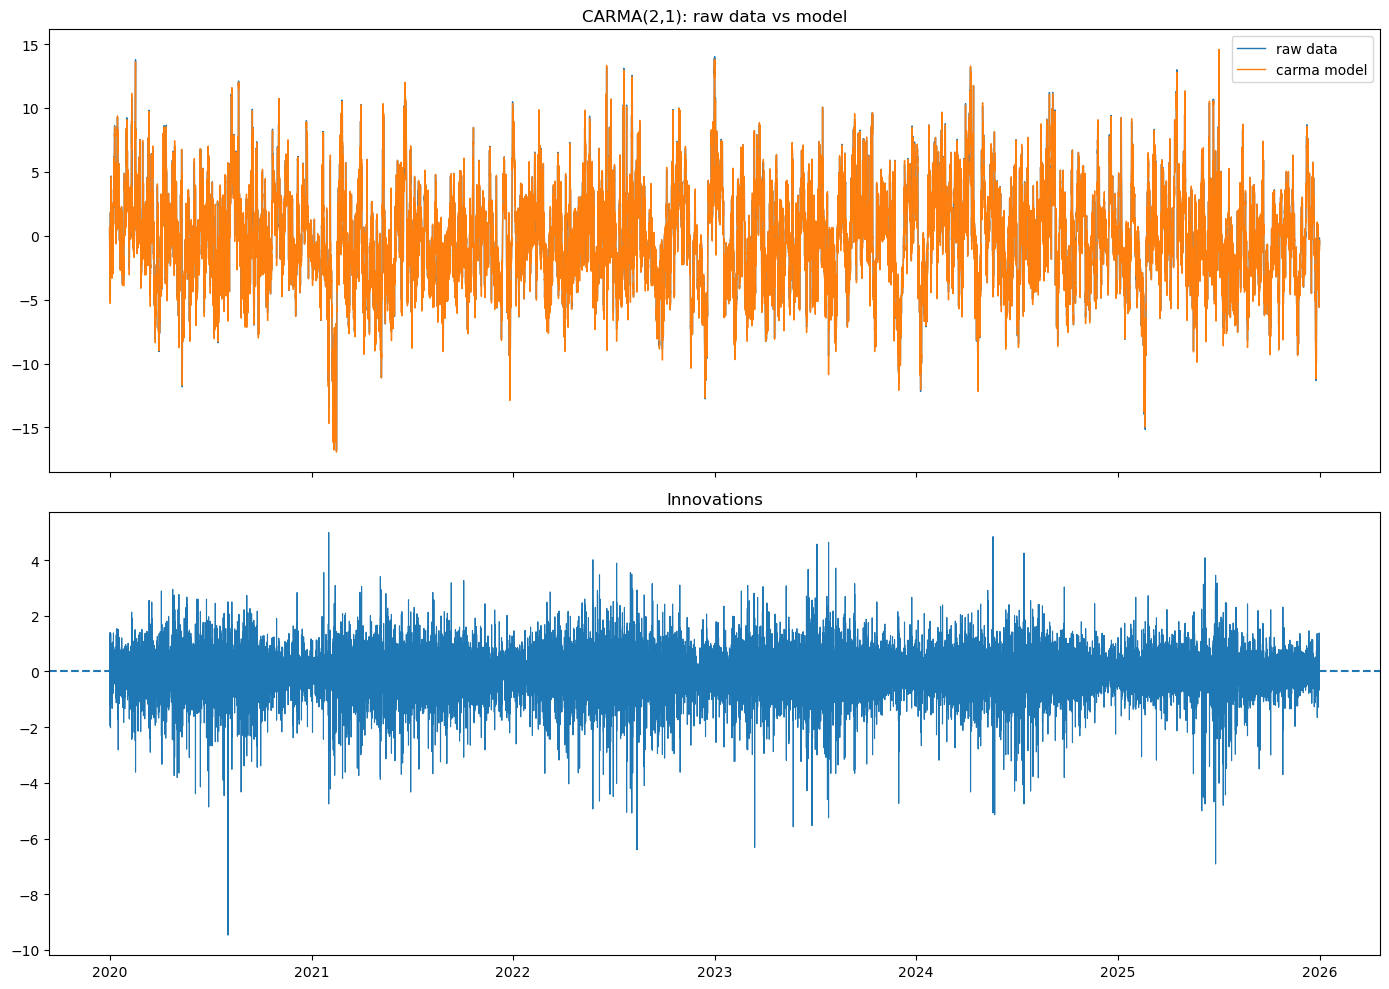

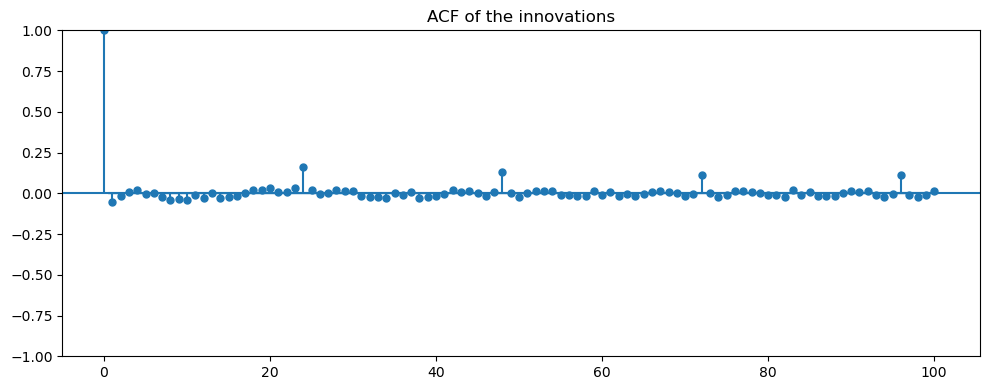

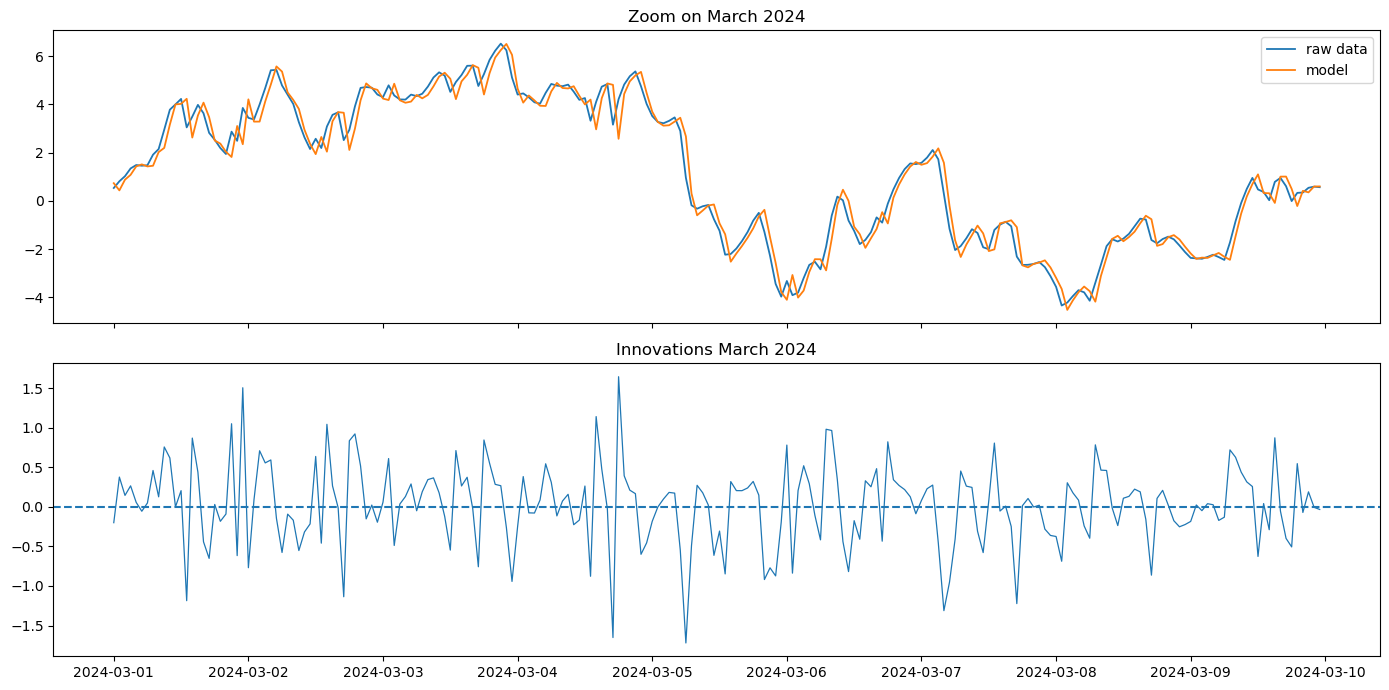

In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(z, lags=[24, 48, 72], return_df=True)
print(lb)

fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(time_temp, y, label="raw data", linewidth=1)
ax[0].plot(time_temp, y_hat, label="carma model", linewidth=1)
ax[0].legend()
ax[0].set_title("CARMA(2,1): raw data vs model")

ax[1].plot(time_temp, innov, linewidth=0.8)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(z, lags=100, ax=ax)
ax.set_title("ACF of the innovations")
plt.tight_layout()
plt.show()

mask_march = (
    (time_temp >= pd.Timestamp("2024-03-01", tz="UTC")) &
    (time_temp <  pd.Timestamp("2024-03-10", tz="UTC"))
)
time_march = time_temp[mask_march]
y_march = y[mask_march]
yhat_march = y_hat[mask_march]
innov_march = innov[mask_march]

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(time_march, y_march, label="raw data", linewidth=1.3)
ax[0].plot(time_march, yhat_march, label="model", linewidth=1.3)
ax[0].legend()
ax[0].set_title("Zoom on March 2024")

ax[1].plot(time_march, innov_march, linewidth=0.9)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations March 2024")

plt.tight_layout()
plt.show()

### CARMA(3,2) — log-price (hourly scale, $h = 1$ hr)

Parameters taken directly from the R QMLE output of notebook 07 Step 2 (hourly time-step $h = 1$ hr). This section validates the Python Kalman filter implementation by replicating the R result at identical parameter values before moving to the final annual-scale model.

The estimated parameters used here are: $a_1 = 5.489$, $a_2 = 3.404$, $a_3 = 0.310$, $b_0 = 1$, $b_1 = 1.420$, $b_2 = 0.036$, $\sigma = 0.0399$.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

price_resid = pd.read_csv("../data/deseasonalised/price_resid_dejumped.csv", index_col=0)
price_res   = price_resid["y_dejumped_interp"].copy()
time_price  = pd.to_datetime(price_res.index)

y = price_res.to_numpy(dtype=float)
t = np.arange(len(y), dtype=float)

# CARMA(3,2) parameters (intermediate estimation, h = 1 hr)
sigma = 0.0399026
b2   = 0.0358923
b0   = 1
b1   = 1.41976
a3   = 0.310356
a2   = 3.4044
a1   = 5.48878

yerr = np.full_like(y, 1e-6, dtype=float)

def kalman_filter_carma32(t, y, a1, a2, a3, b0, b1, b2, sigma,
                          yerr=None, x0=None, P0=None, jitter=1e-10):
    t    = np.asarray(t, dtype=float)
    y    = np.asarray(y, dtype=float)
    yerr = np.full_like(y, 1e-6) if yerr is None else np.asarray(yerr, dtype=float)

    if not np.all(np.diff(t) > 0):
        raise ValueError("Time index must be strictly increasing")

    n, m = len(y), 3

    # Continuous-time CARMA(3,2) companion form
    A = np.array([[0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [-a3, -a2, -a1]], dtype=float)
    L = np.array([[0.0], [0.0], [sigma]], dtype=float)
    H = np.array([[b0, b1, b2]],         dtype=float)

    x_prev = np.zeros(m) if x0 is None else np.asarray(x0, dtype=float)
    P_prev = np.eye(m) * 1000.0 if P0 is None else np.asarray(P0, dtype=float)

    x_pred = np.zeros((n, m));  P_pred = np.zeros((n, m, m))
    x_filt = np.zeros((n, m));  P_filt = np.zeros((n, m, m))
    y_pred = np.zeros(n);  resid = np.zeros(n)
    std_resid = np.zeros(n);  S_all = np.zeros(n)
    loglik = 0.0

    for k in range(n):
        if k == 0:
            xk_pred, Pk_pred = x_prev, P_prev
        else:
            F, Q = van_loan_discretization(A, L, t[k] - t[k - 1])
            xk_pred = F @ x_prev
            Pk_pred = F @ P_prev @ F.T + Q

        Rk = float(yerr[k] ** 2 + jitter)
        mu = float(H @ xk_pred)
        S  = float(H @ Pk_pred @ H.T + Rk)
        v  = y[k] - mu
        K  = (Pk_pred @ H.T) / S

        x_prev = xk_pred + K[:, 0] * v
        P_prev = Pk_pred - K @ H @ Pk_pred

        x_pred[k], P_pred[k] = xk_pred, Pk_pred
        x_filt[k], P_filt[k] = x_prev,  P_prev
        y_pred[k]    = mu
        resid[k]     = v
        std_resid[k] = v / np.sqrt(S)
        S_all[k]     = S
        loglik      += -0.5 * (np.log(2 * np.pi) + np.log(S) + v ** 2 / S)

    return dict(A=A, L=L, H=H,
                x_pred=x_pred, P_pred=P_pred,
                x_filt=x_filt, P_filt=P_filt,
                y_pred=y_pred, resid=resid,
                std_resid=std_resid, S=S_all, loglik=loglik)

res = kalman_filter_carma32(t=t, y=y, a1=a1, a2=a2, a3=a3,
                             b0=b0, b1=b1, b2=b2, sigma=sigma, yerr=yerr)

y_hat        = res["y_pred"]
innov        = res["resid"]
z            = res["std_resid"]
loglik       = res["loglik"]
x_hat        = res["x_pred"]
y_hat_price  = y_hat.copy()
x_hat_price  = x_hat.copy()

aic  = -2 * loglik
rmse = np.sqrt(np.mean((y - y_hat) ** 2))
mae  = np.mean(np.abs(y - y_hat))

print("=== CARMA(3,2) — LOG-PRICE (h = 1 hr) ===")
print(f"  Log-likelihood: {loglik:.4f}")
print(f"  AIC:            {aic:.2f}")
print(f"  RMSE:           {rmse:.6f}")
print(f"  MAE:            {mae:.6f}")
print(f"  Eigenvalues of A: {np.linalg.eigvals(res['A'])}")

lb = acorr_ljungbox(z, lags=[24, 48, 72], return_df=True)
print("\n=== LJUNG-BOX TEST (standardized innovations) ===")
print(lb)


C:\Users\gabri\AppData\Local\Temp\ipykernel_19420\2152148800.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu = float(H @ xk_pred)
C:\Users\gabri\AppData\Local\Temp\ipykernel_19420\2152148800.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S  = float(H @ Pk_pred @ H.T + Rk)


=== CARMA(3,2) — LOG-PRICE (h = 1 hr) ===
  Log-likelihood: 83021.0818
  AIC:            -166042.16
  RMSE:           0.010270
  MAE:            0.006919
  Eigenvalues of A: [-4.79183819 -0.11042817 -0.58651363]

=== LJUNG-BOX TEST (standardized innovations) ===
        lb_stat  lb_pvalue
24  1678.889009        0.0
48  2316.458253        0.0
72  2716.308914        0.0


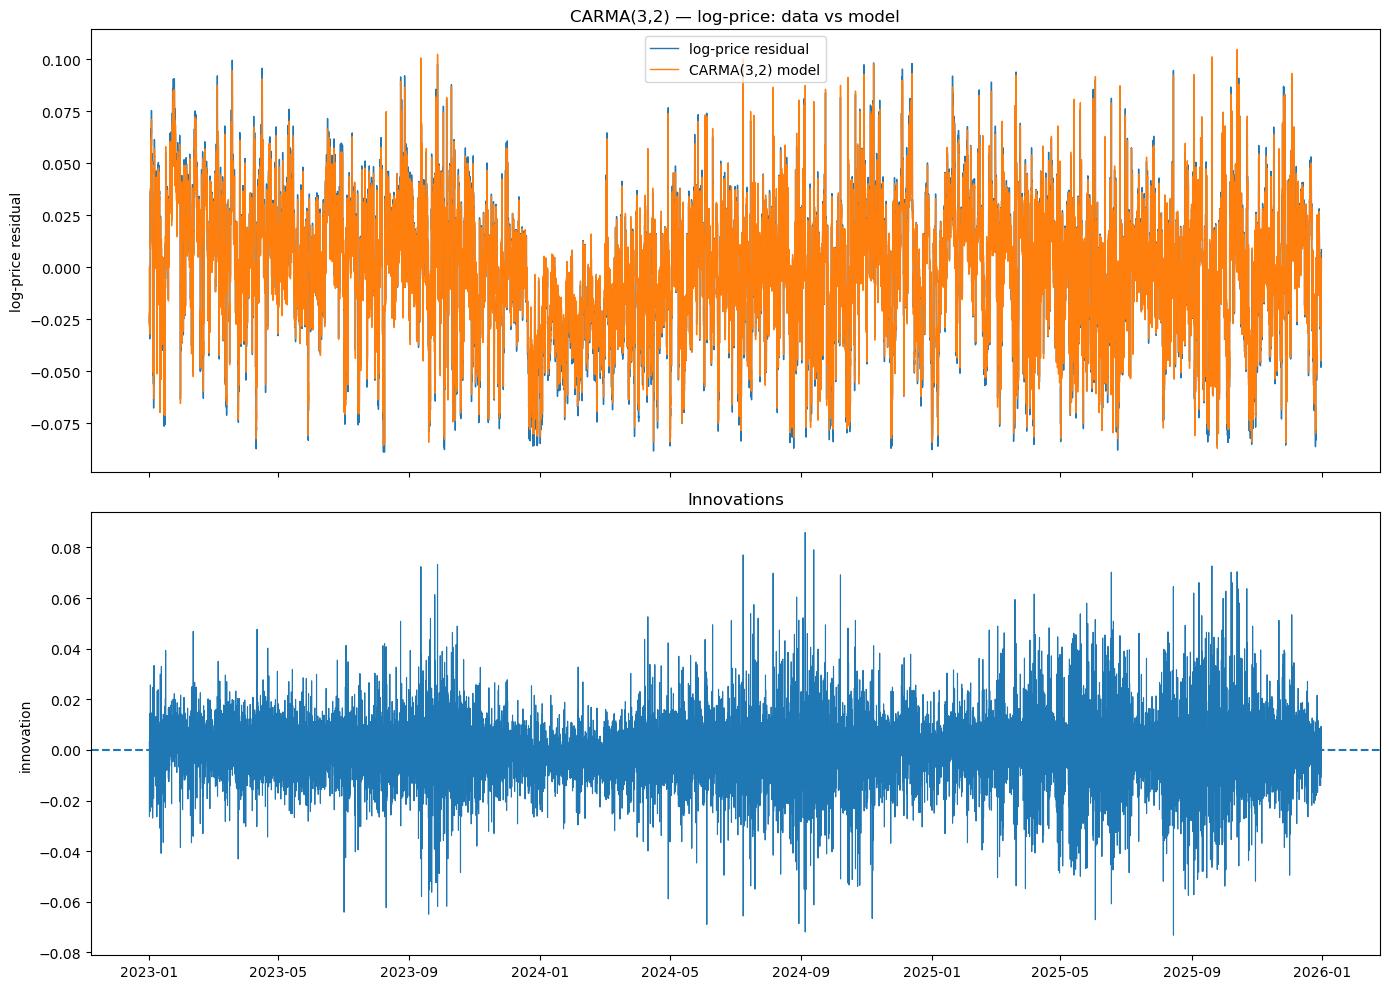

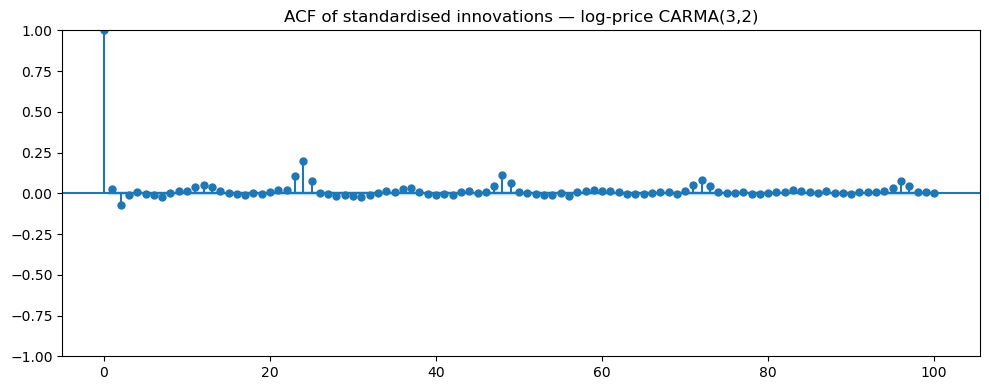

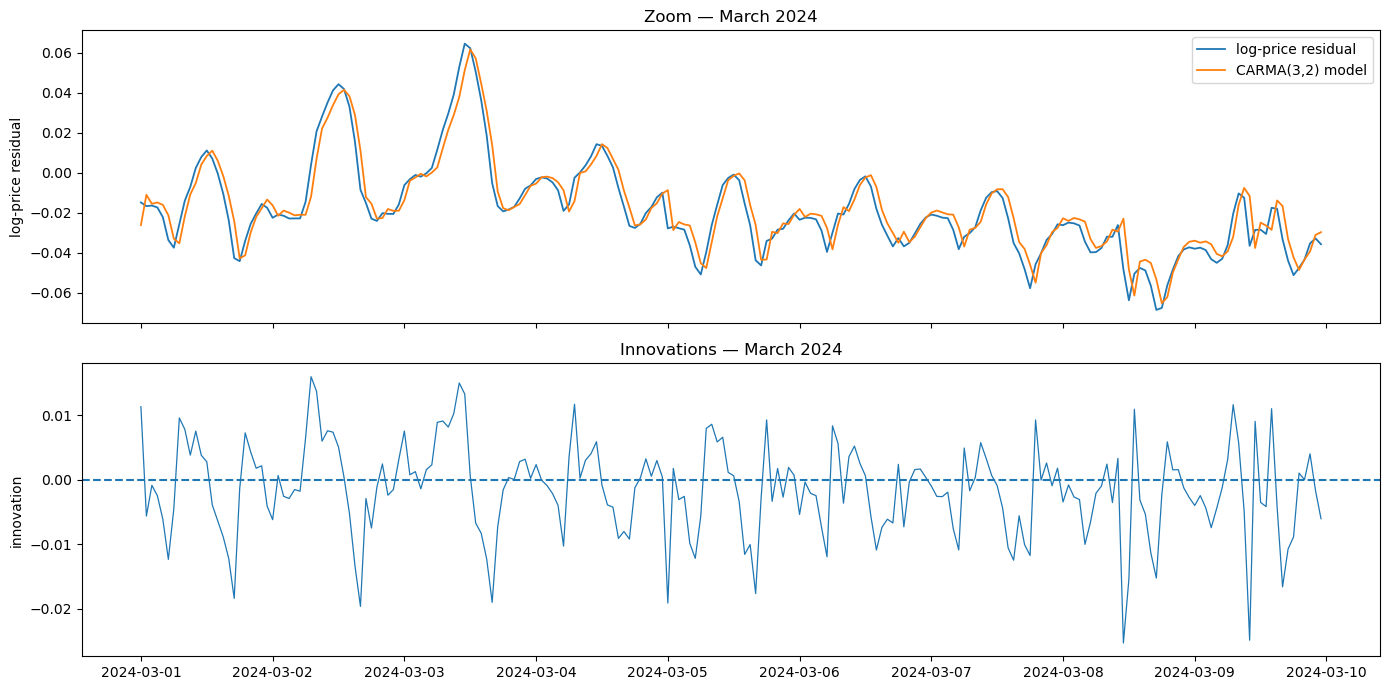

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(time_price, y, label="log-price residual", linewidth=1)
ax[0].plot(time_price, y_hat_price, label="CARMA(3,2) model", linewidth=1)
ax[0].legend()
ax[0].set_title("CARMA(3,2) — log-price: data vs model")
ax[0].set_ylabel("log-price residual")

ax[1].plot(time_price, innov, linewidth=0.8)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations")
ax[1].set_ylabel("innovation")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(z, lags=100, ax=ax)
ax.set_title("ACF of standardised innovations — log-price CARMA(3,2)")
plt.tight_layout()
plt.show()

mask_march = (
    (time_price >= pd.Timestamp("2024-03-01", tz="UTC")) &
    (time_price <  pd.Timestamp("2024-03-10", tz="UTC"))
)
time_march  = time_price[mask_march]
y_march     = y[mask_march]
yhat_march  = y_hat_price[mask_march]
innov_march = innov[mask_march]

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(time_march, y_march,    label="log-price residual", linewidth=1.3)
ax[0].plot(time_march, yhat_march, label="CARMA(3,2) model",   linewidth=1.3)
ax[0].legend()
ax[0].set_title("Zoom — March 2024")
ax[0].set_ylabel("log-price residual")

ax[1].plot(time_march, innov_march, linewidth=0.9)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations — March 2024")
ax[1].set_ylabel("innovation")

plt.tight_layout()
plt.show()